In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = pd.read_csv("../data/listings.csv.gz")
df.shape

(13225, 90)

In [39]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1534226092176355661,https://www.airbnb.com/rooms/1534226092176355661,20260627230126,2026-06-29,city scrape,Private Suite Oceanfront La Jolla,Private suite in Ocean front Estate in La Jolla,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,14064859,...,NaN,NaN,NaN,NaN,NaN,9,6,3,0,NaN
1,1151093362948878244,https://www.airbnb.com/rooms/1151093362948878244,20260627230126,2026-06-29,city scrape,Magical view,Luxury high rise building fully remodeled with...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,365015269,...,NaN,NaN,NaN,STR-08000L,NaN,1,1,0,0,NaN
2,46566873,https://www.airbnb.com/rooms/46566873,20260627230126,2026-06-28,city scrape,Highland on 60th Large 3BR 4 Beds/2 BA Near SDSU,Centrally located single-family home with a la...,NaN,https://a0.muscache.com/pictures/5b341abe-0010...,21897271,...,4.98,4.91,4.91,"STR-01411L, 644117",NaN,1,1,0,0,3.40
3,683340460312082362,https://www.airbnb.com/rooms/683340460312082362,20260627230126,2026-07-02,previous scrape,"Beautiful, Private Bed & Bath in Central Location",Keep it simple at this peaceful and centrally-...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,21788590,...,5.00,4.95,5.00,"STR-06725L, 644561",NaN,2,1,1,0,0.45
4,50119879,https://www.airbnb.com/rooms/50119879,20260627230126,2026-06-29,city scrape,Wooden Craftsman Home w/ Private Backyard & Ga...,Make this entire space your new home away from...,NaN,https://a0.muscache.com/pictures/8b957cbc-f489...,117810403,...,4.93,4.98,4.79,"STR-06662L, 648042",NaN,1,1,0,0,0.95


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13225 entries, 0 to 13224
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            13225 non-null  int64  
 1   listing_url                                   13225 non-null  object 
 2   scrape_id                                     13225 non-null  int64  
 3   last_scraped                                  13225 non-null  object 
 4   source                                        13225 non-null  object 
 5   name                                          13225 non-null  object 
 6   description                                   13088 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   13225 non-null  object 
 9   host_id                                       13225 non-null 

In [41]:
cols = [
    "price", "room_type", "neighbourhood_cleansed", "accommodates",
    "bedrooms", "bathrooms_text", "minimum_nights", "number_of_reviews",
    "review_scores_rating", "host_response_rate", "host_is_superhost",
    "availability_365",
]
df = df[cols].copy()
df.isna().sum()

price                      1369
room_type                     0
neighbourhood_cleansed        0
accommodates                  0
bedrooms                   2034
bathrooms_text               63
minimum_nights               12
number_of_reviews             0
review_scores_rating       2232
host_response_rate        13225
host_is_superhost            32
availability_365              0
dtype: int64

In [42]:
# drop host_response_rate entirely, it's 100% empty
df = df.drop(columns=["host_response_rate"])

# bedrooms: 0 = studio (real value), NaN = missing, only fill the NaNs
median_bedrooms = df["bedrooms"].median()
df["bedrooms"] = df["bedrooms"].fillna(median_bedrooms)

# bathrooms_text, minimum_nights, host_is_superhost: barely any missing, just drop those rows
df = df.dropna(subset=["bathrooms_text", "minimum_nights", "host_is_superhost"])

# review_scores_rating: flag listings with no reviews yet, then fill with median
df["no_reviews_yet"] = df["review_scores_rating"].isna().astype(int)
df["review_scores_rating"] = df["review_scores_rating"].fillna(df["review_scores_rating"].median())

print(df.isna().sum())
print(df.shape)

price                     1363
room_type                    0
neighbourhood_cleansed       0
accommodates                 0
bedrooms                     0
bathrooms_text               0
minimum_nights               0
number_of_reviews            0
review_scores_rating         0
host_is_superhost            0
availability_365             0
no_reviews_yet               0
dtype: int64
(13118, 12)


In [43]:
df["price"] = (
    df["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)
df["price"].describe()

count    11755.000000
mean       477.688482
std        915.436868
min          5.500000
25%        174.450000
50%        321.000000
75%        584.260000
max      82340.820000
Name: price, dtype: float64

In [44]:
df = df[df["price"].between(10, 1000)]
df["price"].describe()

count    10666.000000
mean       351.491485
std        232.567090
min         12.320000
25%        162.722500
50%        289.500000
75%        493.515000
max       1000.000000
Name: price, dtype: float64

/Users/andrewhashoush/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


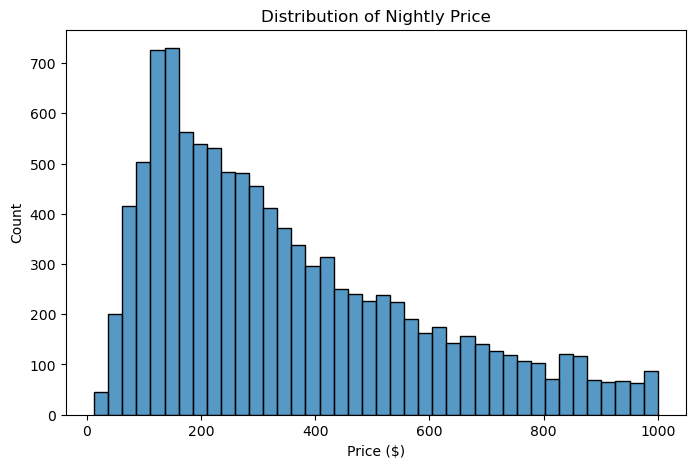

In [45]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=40)
plt.title("Distribution of Nightly Price")
plt.xlabel("Price ($)")
plt.show()

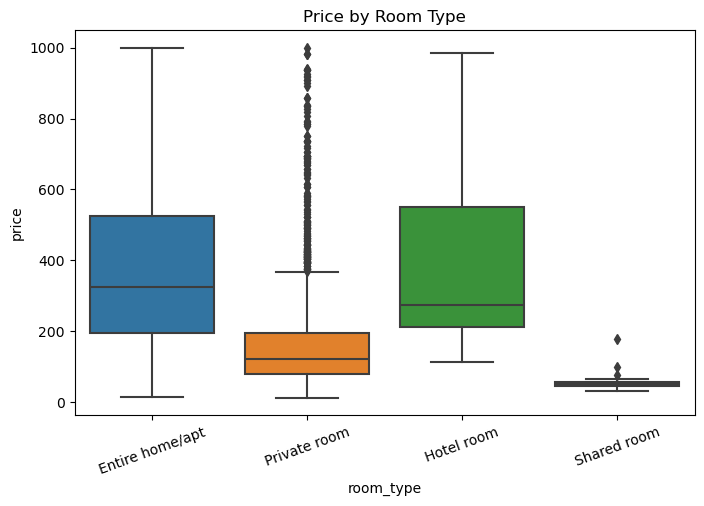

In [46]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="room_type", y="price")
plt.title("Price by Room Type")
plt.xticks(rotation=20)
plt.show()

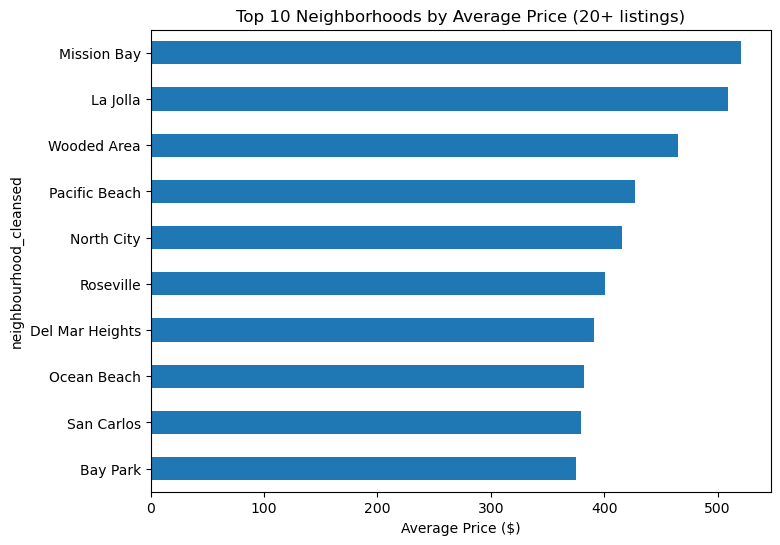

In [47]:
neighborhood_counts = df["neighbourhood_cleansed"].value_counts()
valid_neighborhoods = neighborhood_counts[neighborhood_counts >= 20].index

top_neighborhoods = (
    df[df["neighbourhood_cleansed"].isin(valid_neighborhoods)]
    .groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top_neighborhoods.plot(kind="barh", figsize=(8, 6))
plt.title("Top 10 Neighborhoods by Average Price (20+ listings)")
plt.xlabel("Average Price ($)")
plt.gca().invert_yaxis()
plt.show()

In [48]:
df.groupby("host_is_superhost")["price"].mean()

host_is_superhost
f    311.695077
t    382.510641
Name: price, dtype: float64

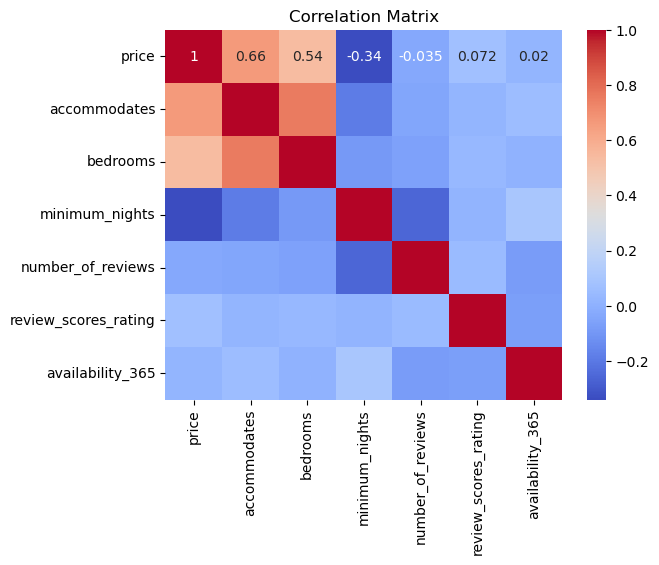

In [49]:
numeric_cols = ["price", "accommodates", "bedrooms", "minimum_nights",
                 "number_of_reviews", "review_scores_rating", "availability_365"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [50]:
df["room_type"].value_counts()

room_type
Entire home/apt    8968
Private room       1506
Hotel room          151
Shared room          41
Name: count, dtype: int64

In [51]:
df["neighbourhood_cleansed"].value_counts()

neighbourhood_cleansed
Mission Bay             1322
Pacific Beach            880
La Jolla                 624
Ocean Beach              556
North Hills              512
                        ... 
Estlake Greens             1
Fenton St                  1
Eastlake Woods             1
Tijuana River Valley       1
Horton Plaza               1
Name: count, Length: 101, dtype: int64

In [52]:
df_model = df.copy()
df_model["bathrooms"] = df_model["bathrooms_text"].str.extract(r"(\d+\.?\d*)").astype(float)
df_model = df_model.dropna(subset=["bathrooms"])

quality_features = ["accommodates", "bedrooms", "bathrooms", "review_scores_rating"]
location_features = ["neighbourhood_cleansed"]
host_features = ["host_is_superhost", "minimum_nights", "number_of_reviews", "availability_365"]

def r2_for_features(data, features, target="price"):
    X = pd.get_dummies(data[features], drop_first=True)
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression().fit(X_train, y_train)
    return r2_score(y_test, model.predict(X_test))

print(f"Quality features alone:  R² = {r2_for_features(df_model, quality_features):.3f}")
print(f"Location alone:          R² = {r2_for_features(df_model, location_features):.3f}")
print(f"Host/profit features:    R² = {r2_for_features(df_model, host_features):.3f}")
print(f"All combined:            R² = {r2_for_features(df_model, quality_features + location_features + host_features):.3f}")

Quality features alone:  R² = 0.408
Location alone:          R² = 0.146
Host/profit features:    R² = 0.141
All combined:            R² = 0.580


In [53]:
X = pd.get_dummies(df_model[quality_features + location_features + host_features], drop_first=True)
y = df_model["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

final_model = LinearRegression().fit(X_train, y_train)

coefs = pd.Series(final_model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coefs.head(15))

neighbourhood_cleansed_La Jolla           222.289642
neighbourhood_cleansed_Mission Bay        200.928864
neighbourhood_cleansed_Torrey Pines       189.377631
neighbourhood_cleansed_Horton Plaza       183.546161
neighbourhood_cleansed_Eastlake Woods     145.524367
neighbourhood_cleansed_Del Mar Heights    143.912744
neighbourhood_cleansed_Pacific Beach      135.643066
neighbourhood_cleansed_Marina             134.006014
neighbourhood_cleansed_Ocean Beach        128.782300
neighbourhood_cleansed_Core               123.061891
neighbourhood_cleansed_Wooded Area        117.859123
neighbourhood_cleansed_East Lake         -116.713695
neighbourhood_cleansed_Columbia           104.627880
neighbourhood_cleansed_Roseville          104.568088
neighbourhood_cleansed_North City          99.062284
dtype: float64


In [54]:
quality_host_coefs = coefs[coefs.index.isin(quality_features + host_features)]
print(quality_host_coefs)

print("\nTop 5 neighborhoods:")
print(coefs[coefs.index.str.startswith("neighbourhood_cleansed")].head(5))

review_scores_rating    47.503327
accommodates            35.982242
bathrooms               30.938053
bedrooms                28.593718
minimum_nights          -2.962701
number_of_reviews       -0.164718
availability_365         0.019720
dtype: float64

Top 5 neighborhoods:
neighbourhood_cleansed_La Jolla          222.289642
neighbourhood_cleansed_Mission Bay       200.928864
neighbourhood_cleansed_Torrey Pines      189.377631
neighbourhood_cleansed_Horton Plaza      183.546161
neighbourhood_cleansed_Eastlake Woods    145.524367
dtype: float64
